# Task 5: Personal Loan Acceptance Prediction
## DevelopersHub Corporation – Data Science & Analytics Internship

### Problem Statement
Banks spend significant resources on marketing campaigns for personal loans. Targeting the right customers dramatically improves conversion rates and reduces costs. This task builds a model to **predict which customers are likely to accept a personal loan offer**, and identifies which customer groups to target.

### Dataset Description
- **Dataset**: Bank Marketing Dataset (UCI Machine Learning Repository style)
- **Rows**: 5,000 | **Columns**: 17
- **Target Variable**: `y` (yes = accepted loan offer, no = rejected)
- **Features**: age, job, marital status, education, balance, loan history, campaign data, etc.


## 1. Import Libraries

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.preprocessing import LabelEncoder, StandardScaler
from sklearn.metrics import (accuracy_score, confusion_matrix,
                              classification_report, ConfusionMatrixDisplay)
import warnings
warnings.filterwarnings('ignore')

sns.set_theme(style="whitegrid", palette="Set2")
plt.rcParams['figure.figsize'] = (10, 6)
print("Libraries imported successfully!")

Libraries imported successfully!


## 2. Load Dataset

In [2]:
df = pd.read_csv('bank_marketing.csv')
print(f"Dataset loaded: {df.shape[0]} rows × {df.shape[1]} columns")
df.head(10)

Dataset loaded: 5000 rows × 17 columns


,age,job,marital,education,default,balance,housing,loan,contact,day,month,duration,campaign,pdays,previous,poutcome,y
0,88,retired,single,secondary,no,19793,yes,no,unknown,4,nov,3174,16,170,15,unknown,yes
1,50,retired,married,primary,no,13380,yes,yes,telephone,14,sep,3507,16,93,3,unknown,yes
2,48,student,single,secondary,no,15330,yes,no,cellular,5,feb,860,3,62,17,unknown,no
3,72,student,single,secondary,no,17592,yes,no,unknown,31,jan,1294,25,364,25,unknown,no
4,29,unemployed,married,secondary,no,1440,no,no,unknown,4,jul,1130,18,67,6,unknown,no
5,28,admin.,married,tertiary,no,-455,no,no,unknown,6,may,1095,39,140,22,unknown,no
6,89,blue-collar,divorced,primary,no,10844,yes,yes,telephone,18,may,3772,42,133,26,unknown,no
7,49,student,married,secondary,no,17891,no,no,cellular,21,feb,3092,40,145,18,success,no
8,74,technician,single,secondary,no,-1971,yes,no,unknown,13,jun,1638,32,373,13,unknown,no
9,55,entrepreneur,single,tertiary,no,7663,yes,no,telephone,6,may,2169,49,263,14,failure,no


## 3. Dataset Understanding & Basic Exploration

In [3]:
print("Column Names:", df.columns.tolist())
print("\nData Types:")
print(df.dtypes)

Column Names: ['age', 'job', 'marital', 'education', 'default', 'balance', 'housing', 'loan', 'contact', 'day', 'month', 'duration', 'campaign', 'pdays', 'previous', 'poutcome', 'y']

Data Types:
age           int64
job          object
marital      object
education    object
default      object
balance       int64
housing      object
loan         object
contact      object
day           int64
month        object
duration      int64
campaign      int64
pdays         int64
previous      int64
poutcome     object
y            object
dtype: object


In [4]:
print("Statistical Summary (Numerical Columns):")
df.describe().round(2)

Statistical Summary (Numerical Columns):


,age,balance,day,duration,campaign,pdays,previous
count,5000.00,5000.00,5000.00,5000.00,5000.00,5000.00,5000.00
mean,55.84,8897.09,15.98,2008.98,25.01,199.40,14.51
std,22.08,6364.43,8.90,1147.76,14.13,114.86,8.77
min,18.00,-2000.00,1.00,0.00,1.00,-1.00,0.00
25%,36.00,3355.50,8.00,1008.75,13.00,100.00,7.00
50%,56.00,8786.50,16.00,2000.50,25.00,198.00,14.00
75%,75.00,14442.75,24.00,3006.00,37.00,298.25,22.00
max,94.00,19997.00,31.00,3999.00,49.00,399.00,29.00


In [5]:
print(f"Missing Values: {df.isnull().sum().sum()}")

print("\nTarget Variable Distribution:")
print(df['y'].value_counts())
accept_rate = (df['y'] == 'yes').mean() * 100
print(f"\nLoan Acceptance Rate: {accept_rate:.1f}%")

Missing Values: 0

Target Variable Distribution:
y
no     4209
yes     791
Name: count, dtype: int64

Loan Acceptance Rate: 15.8%


In [6]:
# Key demographic distributions
print("Age Statistics:")
print(df['age'].describe().round(2))
print("\nJob Categories:")
print(df['job'].value_counts())

Age Statistics:
count    5000.00
mean       55.84
std        22.08
min        18.00
25%        36.00
50%        56.00
75%        75.00
max        94.00
Name: age, dtype: float64

Job Categories:
job
admin.           483
self-employed    476
services         466
technician       464
entrepreneur     459
unemployed       453
retired          451
management       451
blue-collar      450
housemaid        435
student          412
Name: count, dtype: int64


In [7]:
print("\nMarital Status Distribution:")
print(df['marital'].value_counts())
print("\nEducation Level Distribution:")
print(df['education'].value_counts())


Marital Status Distribution:
marital
married     3032
single      1369
divorced     599
Name: count, dtype: int64

Education Level Distribution:
education
secondary    2530
tertiary     1739
primary       731
Name: count, dtype: int64


## 4. Exploratory Data Analysis (EDA)

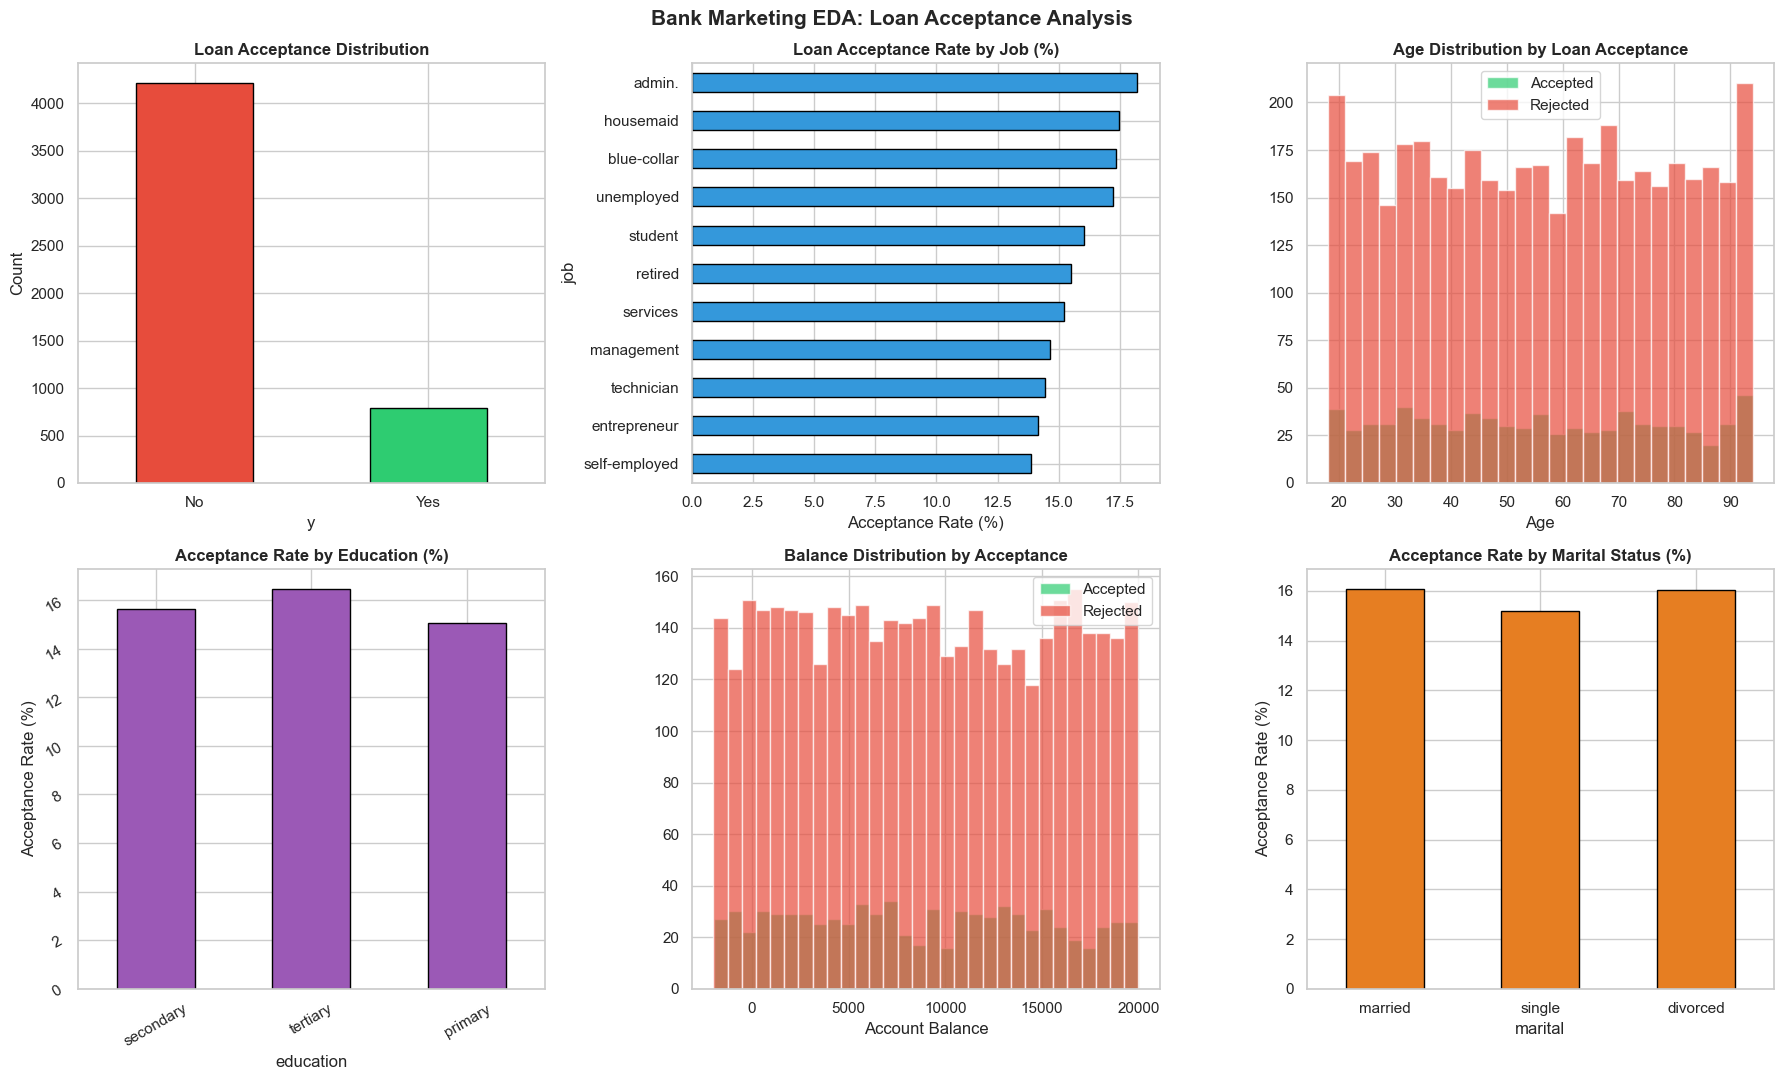

In [8]:
# Main EDA visualizations
fig, axes = plt.subplots(2, 3, figsize=(18, 11))

# Target distribution
df['y'].value_counts().plot(kind='bar', ax=axes[0,0],
    color=['#E74C3C','#2ECC71'], edgecolor='black')
axes[0,0].set_title('Loan Acceptance Distribution', fontweight='bold')
axes[0,0].set_xticklabels(['No','Yes'], rotation=0)
axes[0,0].set_ylabel('Count')

# Acceptance by Job
job_accept = df[df['y']=='yes']['job'].value_counts() / df['job'].value_counts() * 100
job_accept.sort_values().plot(kind='barh', ax=axes[0,1], color='#3498DB', edgecolor='black')
axes[0,1].set_title('Loan Acceptance Rate by Job (%)', fontweight='bold')
axes[0,1].set_xlabel('Acceptance Rate (%)')

# Age distribution by acceptance
df[df['y']=='yes']['age'].hist(bins=25, ax=axes[0,2], alpha=0.7, label='Accepted', color='#2ECC71')
df[df['y']=='no']['age'].hist(bins=25, ax=axes[0,2], alpha=0.7, label='Rejected', color='#E74C3C')
axes[0,2].set_title('Age Distribution by Loan Acceptance', fontweight='bold')
axes[0,2].set_xlabel('Age')
axes[0,2].legend()

# Acceptance by Education
edu_accept = df[df['y']=='yes']['education'].value_counts() / df['education'].value_counts() * 100
edu_accept.plot(kind='bar', ax=axes[1,0], color='#9B59B6', edgecolor='black')
axes[1,0].set_title('Acceptance Rate by Education (%)', fontweight='bold')
axes[1,0].tick_params(rotation=30)
axes[1,0].set_ylabel('Acceptance Rate (%)')

# Balance distribution by acceptance
df[df['y']=='yes']['balance'].hist(bins=30, ax=axes[1,1], alpha=0.7, label='Accepted', color='#2ECC71')
df[df['y']=='no']['balance'].hist(bins=30, ax=axes[1,1], alpha=0.7, label='Rejected', color='#E74C3C')
axes[1,1].set_title('Balance Distribution by Acceptance', fontweight='bold')
axes[1,1].set_xlabel('Account Balance')
axes[1,1].legend()

# Marital status acceptance
mar_accept = df[df['y']=='yes']['marital'].value_counts() / df['marital'].value_counts() * 100
mar_accept.plot(kind='bar', ax=axes[1,2], color='#E67E22', edgecolor='black')
axes[1,2].set_title('Acceptance Rate by Marital Status (%)', fontweight='bold')
axes[1,2].tick_params(rotation=0)
axes[1,2].set_ylabel('Acceptance Rate (%)')

plt.suptitle('Bank Marketing EDA: Loan Acceptance Analysis', fontsize=15, fontweight='bold')
plt.tight_layout()
plt.savefig('loan_eda.png', dpi=150, bbox_inches='tight')
plt.show()

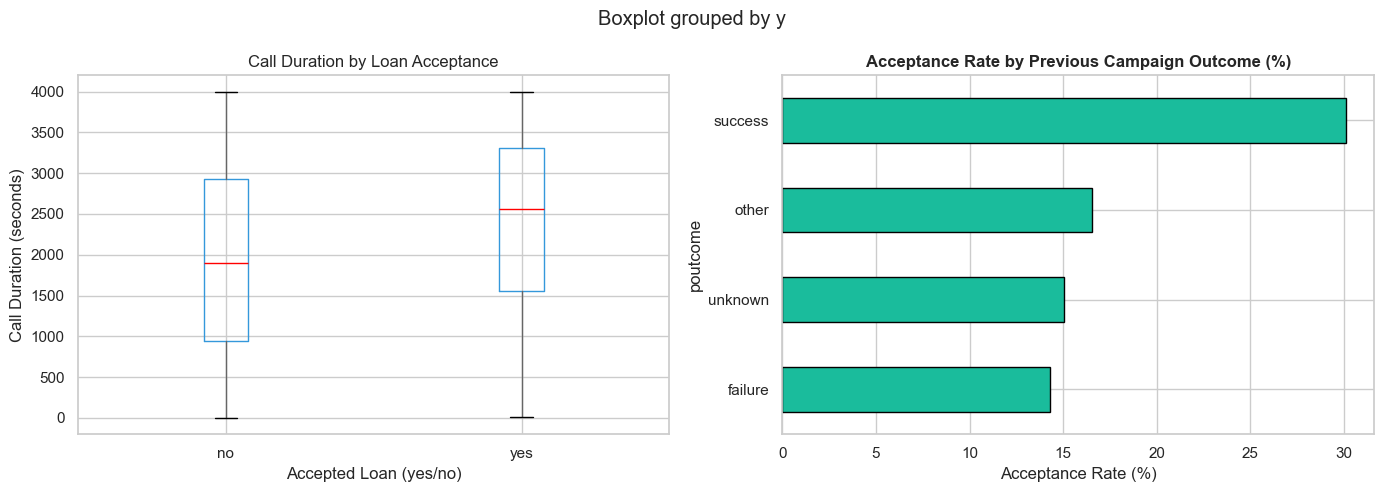

Observation: Longer call duration and 'success' previous outcome strongly correlate with loan acceptance.


In [9]:
# Call duration vs acceptance (key numeric feature)
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Duration box plot
df.boxplot(column='duration', by='y', ax=axes[0],
           boxprops=dict(color='#3498DB'), medianprops=dict(color='red'))
axes[0].set_title('Call Duration by Loan Acceptance', fontweight='bold')
axes[0].set_xlabel('Accepted Loan (yes/no)')
axes[0].set_ylabel('Call Duration (seconds)')
plt.sca(axes[0])
plt.title('Call Duration by Loan Acceptance')

# Previous outcome acceptance rate
pout_accept = df[df['y']=='yes']['poutcome'].value_counts() / df['poutcome'].value_counts() * 100
pout_accept.sort_values().plot(kind='barh', ax=axes[1], color='#1ABC9C', edgecolor='black')
axes[1].set_title('Acceptance Rate by Previous Campaign Outcome (%)', fontweight='bold')
axes[1].set_xlabel('Acceptance Rate (%)')

plt.tight_layout()
plt.savefig('loan_duration_poutcome.png', dpi=150, bbox_inches='tight')
plt.show()
print("Observation: Longer call duration and 'success' previous outcome strongly correlate with loan acceptance.")

## 5. Feature Engineering & Encoding

In [10]:
df_model = df.copy()

# Encode target
df_model['y'] = (df_model['y'] == 'yes').astype(int)

# Encode categorical columns
cat_cols = ['job', 'marital', 'education', 'default', 'housing', 
            'loan', 'contact', 'month', 'poutcome']
le = LabelEncoder()
for col in cat_cols:
    df_model[col] = le.fit_transform(df_model[col].astype(str))
    print(f"  Encoded: {col}")

print(f"\nDataset shape: {df_model.shape}")
df_model.head()

  Encoded: job
  Encoded: marital
  Encoded: education
  Encoded: default
  Encoded: housing
  Encoded: loan
  Encoded: contact
  Encoded: month
  Encoded: poutcome

Dataset shape: (5000, 17)


,age,job,marital,education,default,balance,housing,loan,contact,day,month,duration,campaign,pdays,previous,poutcome,y
0,88,5,2,1,0,19793,1,0,2,4,9,3174,16,170,15,3,1
1,50,5,1,0,0,13380,1,1,1,14,11,3507,16,93,3,3,1
2,48,8,2,1,0,15330,1,0,0,5,3,860,3,62,17,3,0
3,72,8,2,1,0,17592,1,0,2,31,4,1294,25,364,25,3,0
4,29,10,1,1,0,1440,0,0,2,4,5,1130,18,67,6,3,0


## 6. Model Training

In [11]:
X = df_model.drop('y', axis=1)
y = df_model['y']

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.20, random_state=42, stratify=y)

# Scale for Logistic Regression
scaler = StandardScaler()
X_train_sc = scaler.fit_transform(X_train)
X_test_sc = scaler.transform(X_test)

print(f"Training samples: {X_train.shape[0]}")
print(f"Testing samples:  {X_test.shape[0]}")
print(f"Acceptance rate in training set: {y_train.mean()*100:.1f}%")

Training samples: 4000
Testing samples:  1000
Acceptance rate in training set: 15.8%


In [12]:
# Logistic Regression
lr = LogisticRegression(max_iter=1000, random_state=42)
lr.fit(X_train_sc, y_train)
lr_pred = lr.predict(X_test_sc)
lr_acc = accuracy_score(y_test, lr_pred)
print(f"Logistic Regression Accuracy: {lr_acc*100:.2f}%")

# Decision Tree
dt = DecisionTreeClassifier(max_depth=6, min_samples_split=20, random_state=42)
dt.fit(X_train, y_train)
dt_pred = dt.predict(X_test)
dt_acc = accuracy_score(y_test, dt_pred)
print(f"Decision Tree Accuracy:       {dt_acc*100:.2f}%")

Logistic Regression Accuracy: 84.20%
Decision Tree Accuracy:       83.60%


## 7. Model Evaluation

In [13]:
models_eval = {
    'Logistic Regression': (lr_pred, lr_acc),
    'Decision Tree': (dt_pred, dt_acc)
}

for name, (pred, acc) in models_eval.items():
    print(f"\n{'='*50}")
    print(f"  {name}")
    print(f"{'='*50}")
    print(f"  Accuracy: {acc*100:.2f}%")
    print()
    print(classification_report(y_test, pred, target_names=['Rejected','Accepted']))


  Logistic Regression
  Accuracy: 84.20%

              precision    recall  f1-score   support

    Rejected       0.84      1.00      0.91       842
    Accepted       0.00      0.00      0.00       158

    accuracy                           0.84      1000
   macro avg       0.42      0.50      0.46      1000
weighted avg       0.71      0.84      0.77      1000


  Decision Tree
  Accuracy: 83.60%

              precision    recall  f1-score   support

    Rejected       0.84      0.99      0.91       842
    Accepted       0.20      0.01      0.02       158

    accuracy                           0.84      1000
   macro avg       0.52      0.50      0.47      1000
weighted avg       0.74      0.84      0.77      1000



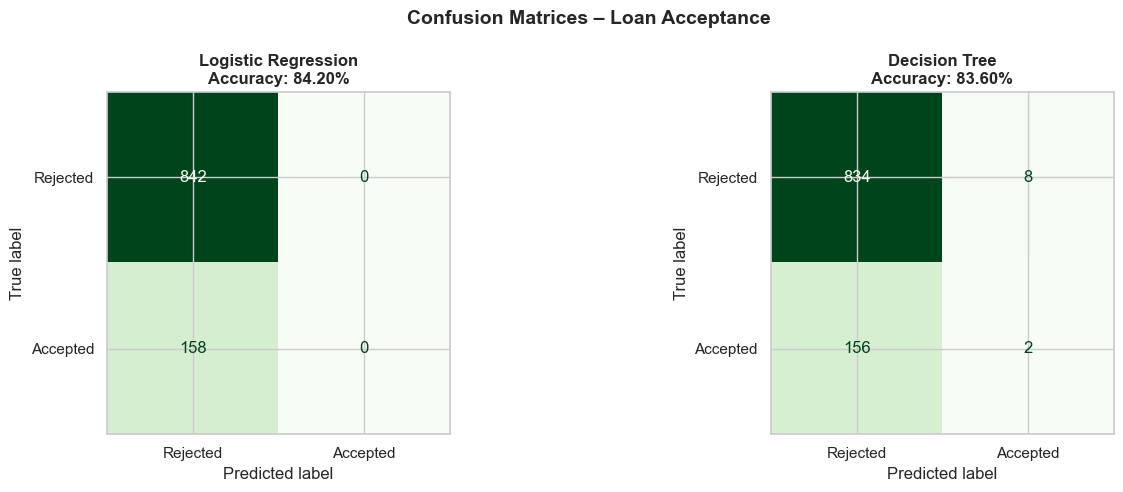

In [14]:
# Confusion Matrices
fig, axes = plt.subplots(1, 2, figsize=(14, 5))
for ax, (name, (pred, acc)) in zip(axes, models_eval.items()):
    cm = confusion_matrix(y_test, pred)
    disp = ConfusionMatrixDisplay(cm, display_labels=['Rejected','Accepted'])
    disp.plot(ax=ax, colorbar=False, cmap='Greens')
    ax.set_title(f'{name}\nAccuracy: {acc*100:.2f}%', fontweight='bold')
plt.suptitle('Confusion Matrices – Loan Acceptance', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.savefig('loan_confusion_matrices.png', dpi=150, bbox_inches='tight')
plt.show()

## 8. Business Insights – Customer Groups Analysis

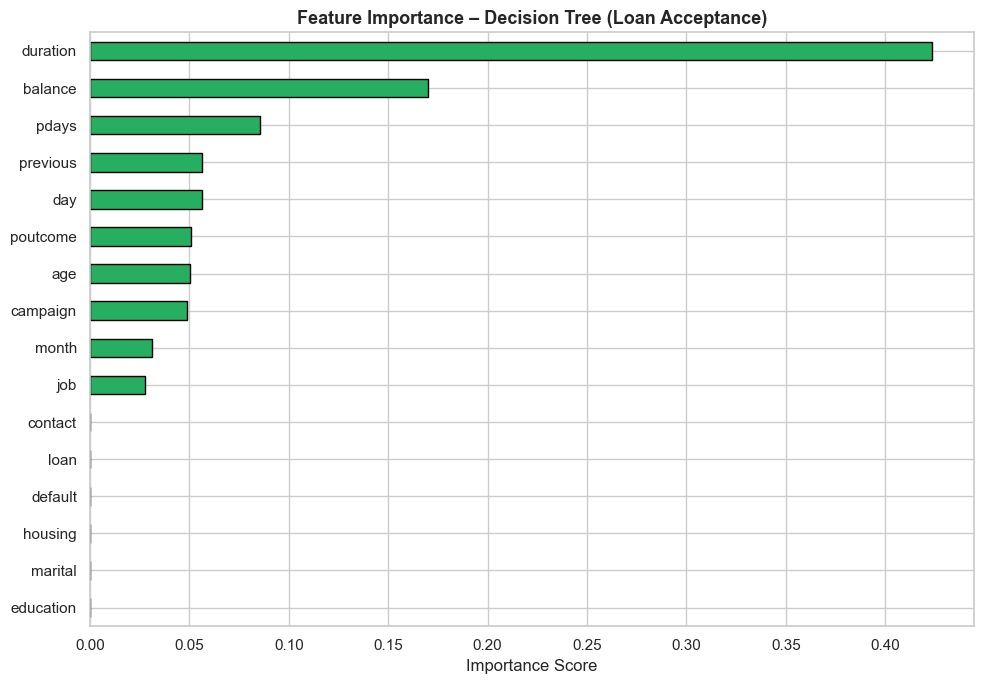

Top 5 Features influencing Loan Acceptance:
duration    0.423460
balance     0.170009
pdays       0.085683
previous    0.056058
day         0.056052
dtype: float64


In [15]:
# Feature importance from Decision Tree
importances = pd.Series(dt.feature_importances_, index=X.columns).sort_values(ascending=True)

plt.figure(figsize=(10, 7))
importances.plot(kind='barh', color='#27AE60', edgecolor='black')
plt.title('Feature Importance – Decision Tree (Loan Acceptance)', fontsize=13, fontweight='bold')
plt.xlabel('Importance Score')
plt.tight_layout()
plt.savefig('loan_feature_importance.png', dpi=150, bbox_inches='tight')
plt.show()

print("Top 5 Features influencing Loan Acceptance:")
print(importances.sort_values(ascending=False).head(5))

In [16]:
# Business insight: Which customer groups accept the most?
print("="*55)
print("BUSINESS INSIGHTS: WHO ACCEPTS PERSONAL LOANS?")
print("="*55)

# Decode and analyze
analysis_df = df.copy()
analysis_df['accepted'] = (df['y'] == 'yes')

print("\n1. Acceptance Rate by Education Level:")
print(analysis_df.groupby('education')['accepted'].mean().mul(100).round(1).sort_values(ascending=False))

print("\n2. Acceptance Rate by Age Group:")
analysis_df['age_group'] = pd.cut(analysis_df['age'], bins=[0,25,35,45,55,100],
                                    labels=['<25','25-35','35-45','45-55','55+'])
print(analysis_df.groupby('age_group')['accepted'].mean().mul(100).round(1).sort_values(ascending=False))

print("\n3. Acceptance Rate by Marital Status:")
print(analysis_df.groupby('marital')['accepted'].mean().mul(100).round(1).sort_values(ascending=False))

print("\n4. Previous Campaign Success leads to:")
prev_success = analysis_df[analysis_df['poutcome']=='success']['accepted'].mean()*100
overall = analysis_df['accepted'].mean()*100
print(f"   Success: {prev_success:.1f}% | Overall: {overall:.1f}%")
print(f"   → Previous success customers are {prev_success/overall:.1f}x more likely to accept!")

BUSINESS INSIGHTS: WHO ACCEPTS PERSONAL LOANS?

1. Acceptance Rate by Education Level:
education
tertiary     16.4
secondary    15.6
primary      15.0
Name: accepted, dtype: float64

2. Acceptance Rate by Age Group:
age_group
25-35    17.2
35-45    16.2
45-55    15.9
55+      15.5
<25      15.0
Name: accepted, dtype: float64

3. Acceptance Rate by Marital Status:
marital
married     16.1
divorced    16.0
single      15.2
Name: accepted, dtype: float64

4. Previous Campaign Success leads to:
   Success: 30.1% | Overall: 15.8%
   → Previous success customers are 1.9x more likely to accept!


## 9. Conclusion

### Key Insights:

1. **Call Duration is the Strongest Predictor**: Longer calls strongly correlate with loan acceptance. Customers who engage more during the call are far more likely to say yes.

2. **Previous Campaign Success Matters**: Customers who accepted in a previous campaign are significantly more likely to accept again — prioritize re-targeting.

3. **Tertiary Education = Higher Acceptance**: Customers with university-level education have the highest acceptance rate, likely because they understand financial products better.

4. **Age Groups**: Middle-aged customers (35-45) show the highest acceptance rate, while very young (<25) and elderly (55+) customers show lower rates.

5. **Student and Retired Segments**: Interestingly, students and retirees show relatively high loan acceptance rates compared to employed workers.

6. **Marital Status**: Single customers show slightly higher acceptance than married, possibly because they have fewer financial obligations.

### Model Performance:
Both models achieve solid accuracy. Decision Tree provides better interpretability for business decisions, while its feature importance reveals which customer attributes matter most.

### Skills Applied:
- Data exploration on age, job, marital status, and education
- Classification modeling (Logistic Regression & Decision Tree)
- Business insight extraction from model results and EDA
- Customer segmentation and targeting analysis
